In [3]:
import pandas as pd

df = pd.read_csv("feeds (2).csv")

print(df.shape)
print(df['created_at'].min())
print(df['created_at'].max())

(30869, 14)
2026-05-16T08:00:02+00:00
2026-06-24T10:09:03+00:00


In [4]:
import pandas as pd

df = pd.read_csv("feeds (2).csv")

df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at')

print("Jumlah data :", len(df))
print("Awal        :", df['created_at'].min())
print("Akhir       :", df['created_at'].max())

df['time_diff'] = df['created_at'].diff()

print("\nGap terbesar:")
print(df['time_diff'].max())

Jumlah data : 30869
Awal        : 2026-05-16 08:00:02+00:00
Akhir       : 2026-06-24 10:09:03+00:00

Gap terbesar:
6 days 13:40:00


In [5]:
gaps = df[df['time_diff'] > pd.Timedelta(minutes=1)]

print("Jumlah gap:", len(gaps))

print("\n10 gap terbesar:")
print(
    gaps[['created_at','time_diff']]
    .sort_values('time_diff', ascending=False)
    .head(10)
)

Jumlah gap: 5847

10 gap terbesar:
                     created_at       time_diff
9129  2026-06-04 08:31:15+00:00 6 days 13:40:00
18035 2026-06-15 07:49:27+00:00 2 days 22:19:02
6357  2026-05-25 15:10:13+00:00 1 days 07:59:05
6146  2026-05-24 03:37:12+00:00 0 days 20:31:04
9301  2026-06-05 07:05:20+00:00 0 days 19:43:05
6531  2026-05-26 07:45:13+00:00 0 days 13:42:04
3654  2026-05-19 23:13:08+00:00 0 days 12:12:03
6094  2026-05-23 06:11:11+00:00 0 days 12:11:04
17066 2026-06-11 05:08:24+00:00 0 days 10:45:00
4400  2026-05-21 01:49:09+00:00 0 days 10:00:04


In [6]:
df = df.set_index('created_at')

hourly = df['field7'].resample('H').mean()

print("Jumlah jam:", len(hourly))
print("Jam kosong:", hourly.isna().sum())

Jumlah jam: 939
Jam kosong: 384


/tmp/ipykernel_9873/344681794.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df['field7'].resample('H').mean()


In [7]:
print(hourly[hourly.isna()])

created_at
2026-05-16 19:00:00+00:00   NaN
2026-05-16 20:00:00+00:00   NaN
2026-05-16 21:00:00+00:00   NaN
2026-05-17 20:00:00+00:00   NaN
2026-05-17 21:00:00+00:00   NaN
                             ..
2026-06-15 02:00:00+00:00   NaN
2026-06-15 03:00:00+00:00   NaN
2026-06-15 04:00:00+00:00   NaN
2026-06-15 05:00:00+00:00   NaN
2026-06-15 06:00:00+00:00   NaN
Name: field7, Length: 384, dtype: float64


In [8]:
hourly_raw = df['field7'].resample('h').mean()

print("NaN awal :", hourly_raw.isna().sum())

hourly_clean = hourly_raw.interpolate(limit=3)

hourly_clean = hourly_clean.dropna()

print("NaN akhir :", hourly_clean.isna().sum())

print("Jumlah data bersih :", len(hourly_clean))

NaN awal : 384
NaN akhir : 0
Jumlah data bersih : 608


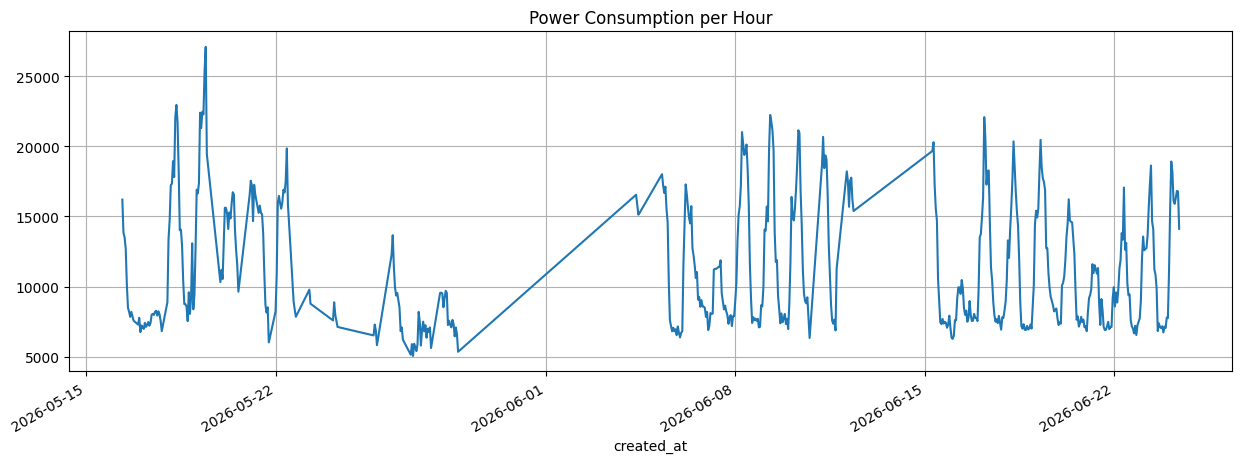

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
hourly_clean.plot()
plt.title("Power Consumption per Hour")
plt.grid(True)
plt.show()

In [10]:
print("Jumlah data bersih :", len(hourly_clean))

Jumlah data bersih : 608


# Random Forest

In [11]:
rf_df = pd.DataFrame(hourly_clean)

rf_df.columns = ['power']

for lag in [1,2,3,6,12,24]:
    rf_df[f'lag_{lag}'] = rf_df['power'].shift(lag)

rf_df = rf_df.dropna()

print(rf_df.shape)

(584, 7)


In [12]:
X = rf_df.drop('power', axis=1)
y = rf_df['power']

split = int(len(rf_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (467, 6)
Test : (117, 6)


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [14]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

best_rf = grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

MAE : 991.3285694702939
RMSE: 1385.2230443356887
R2  : 0.8206922207557203


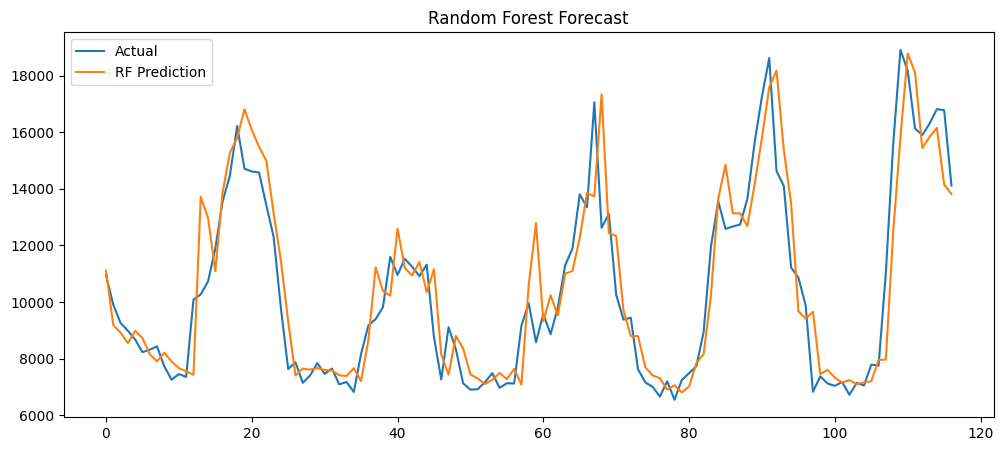

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_rf, label='RF Prediction')
plt.title('Random Forest Forecast')
plt.legend()
plt.show()

  Feature  Importance
0   lag_1    0.894577
3   lag_6    0.027230
2   lag_3    0.025287
5  lag_24    0.023279
1   lag_2    0.015085
4  lag_12    0.014542


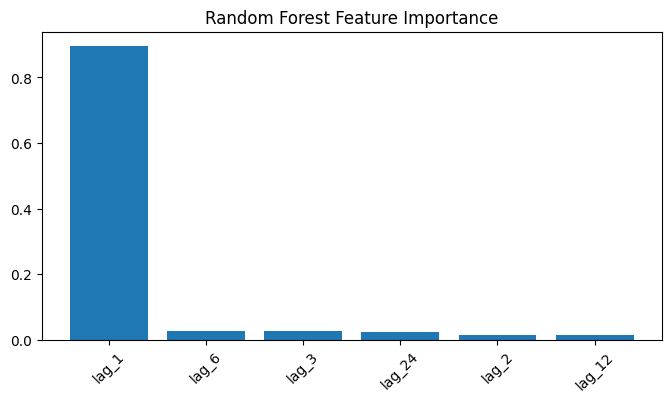

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = [
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_6',
    'lag_12',
    'lag_24'
]

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,4))
plt.bar(
    importance['Feature'],
    importance['Importance']
)
plt.title('Random Forest Feature Importance')
plt.xticks(rotation=45)
plt.show()

In [17]:
import joblib

joblib.dump(best_rf, "rf_model.pkl")

['rf_model.pkl']

# LSTM

In [18]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    hourly_clean.values.reshape(-1,1)
)

In [19]:
X = []
y = []

window = 24

for i in range(window, len(scaled_data)):
    X.append(scaled_data[i-window:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(584, 24, 1)
(584, 1)


In [20]:
print("NaN X =", np.isnan(X).sum())
print("NaN y =", np.isnan(y).sum())

NaN X = 0
NaN y = 0


In [21]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(24,1)),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0582 - val_loss: 0.0446
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0340 - val_loss: 0.0359
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0299 - val_loss: 0.0286
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0243 - val_loss: 0.0201
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0185 - val_loss: 0.0102
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0148 - val_loss: 0.0087
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0129 - val_loss: 0.0075
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0119 - val_loss: 0.0075
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0109 - val_loss: 0.0068
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0107 - val_loss: 0.0067
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0096 - val_loss: 0.0061
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0094 - val_l

In [25]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# ==========================
# PREDIKSI LSTM
# ==========================

y_pred_lstm = model.predict(X_test)

y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_test_inv = scaler.inverse_transform(y_test)

print("Shape pred :", y_pred_lstm.shape)
print("Shape test :", y_test_inv.shape)

print("NaN pred :", np.isnan(y_pred_lstm).sum())
print("NaN test :", np.isnan(y_test_inv).sum())

# ==========================
# EVALUASI
# ==========================

mae_lstm = mean_absolute_error(
    y_test_inv.ravel(),
    y_pred_lstm.ravel()
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        y_test_inv.ravel(),
        y_pred_lstm.ravel()
    )
)

r2_lstm = r2_score(
    y_test_inv.ravel(),
    y_pred_lstm.ravel()
)

print("MAE :", mae_lstm)
print("RMSE:", rmse_lstm)
print("R2  :", r2_lstm)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step
Shape pred : (117, 1)
Shape test : (117, 1)
NaN pred : 0
NaN test : 0
MAE : 993.3936264909091
RMSE: 1313.8802330341346
R2  : 0.8386862920842137


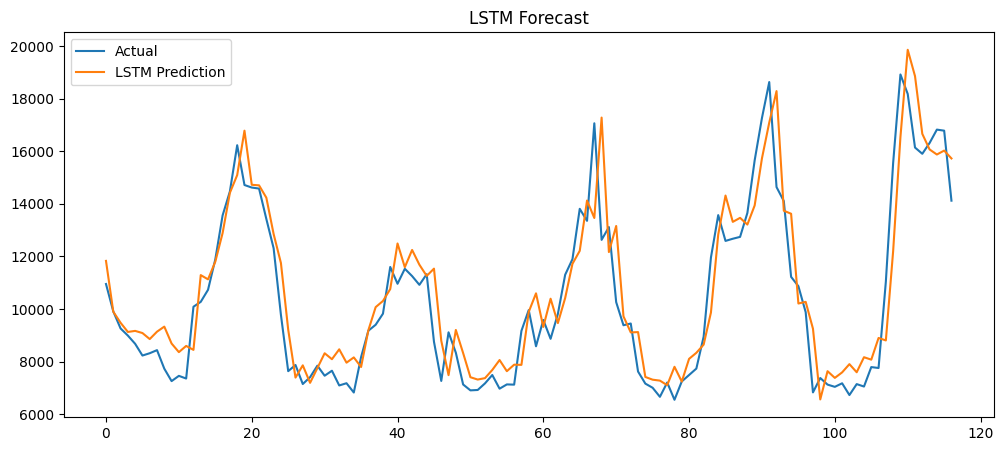

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    y_test_inv,
    label='Actual'
)

plt.plot(
    y_pred_lstm,
    label='LSTM Prediction'
)

plt.title('LSTM Forecast')
plt.legend()
plt.show()

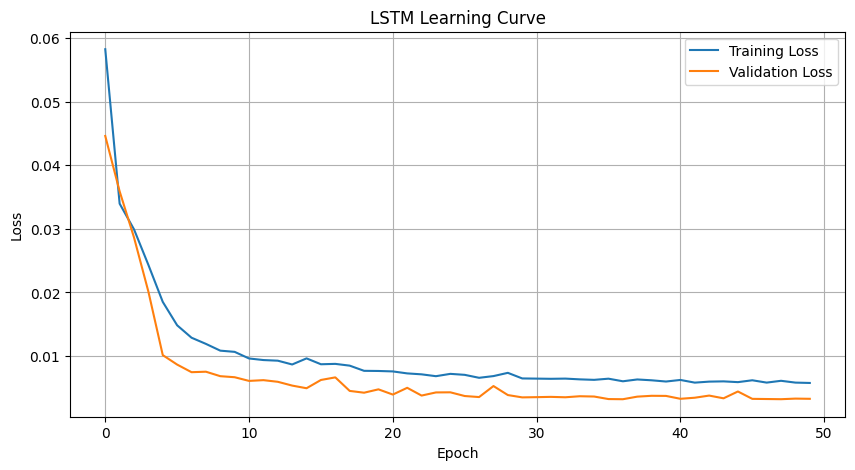

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [28]:
import os
import joblib
from tensorflow.keras.models import load_model

joblib.dump(best_rf, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
model.save("lstm_model.keras")

print(os.listdir())

rf_loaded = joblib.load("rf_model.pkl")
print(type(rf_loaded))

scaler_loaded = joblib.load("scaler.pkl")
print(type(scaler_loaded))

lstm_loaded = load_model("lstm_model.keras")

lstm_loaded.summary()

['.config', '.ipynb_checkpoints', 'lstm_model.keras', 'rf_model.pkl', 'scaler.pkl', 'feeds (2).csv', 'sample_data']
<class 'sklearn.ensemble._forest.RandomForestRegressor'>
<class 'sklearn.preprocessing._data.MinMaxScaler'>


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,885 (198.77 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 33,924 (132.52 KB)

In [29]:
print(hourly.isna().sum())
print(hourly_clean.isna().sum())

print(len(y_test))
print(len(y_pred_rf))

print(len(y_test_inv))
print(len(y_pred_lstm))

384
0
117
117
117
117
